# 01 — Exploratory Data Analysis: canerkonuk (train)

Loads the cleaned `data/processed/train.parquet` (canerkonuk, our sole training source), applies `build_features` from `src/features.py`, and looks at distributions, correlations with `video_view_count`, and category/country breakdowns. The category and country charts are also saved to `reports/figures/` for the geographic bias write-up.

In [1]:
import sys
sys.path.append('../src')

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from features import build_features

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path('../data/processed/train.parquet')
df = pd.read_parquet(DATA_PATH)
df = build_features(df)
print(f"Loaded and featurized {len(df):,} rows")
df.head(3)

Loaded and featurized 9,876,866 rows


,video_id,video_published_at,video_trending__date,video_trending_country,channel_id,video_title,video_description,video_default_thumbnail,video_category_id,video_tags,video_duration,video_dimension,video_definition,video_licensed_content,video_view_count,video_like_count,video_comment_count,channel_title,channel_description,channel_custom_url,channel_published_at,channel_country,channel_view_count,channel_subscriber_count,channel_have_hidden_subscribers,channel_video_count,channel_localized_title,channel_localized_description,trending_date,publish_hour,publish_dayofweek,days_to_trend,tag_count,title_length,title_has_caps_word,comment_rate,channel_engagement_rate
0,bB3-CUMERIU,2024-10-11T00:00:06Z,2024.10.12,United Arab Emirates,UCNYi_zGmR519r5gYdOKLTjQ,JENNIE - Mantra (Official Music Video),Official music video for “Mantra” by JENNIE ou...,https://i.ytimg.com/vi/bB3-CUMERIU/default.jpg,Music,"JENNIE,Mantra,제니,Jennie Mantra,Jennie from Bla...",PT2M28S,2d,hd,False,20535235,2042255,152933,JENNIE,NaN,@jennierubyjane,2021-01-13T06:19:55.86689Z,NaN,464615150,11600000,false,43,JENNIE,NaN,2024-10-12,0,4,0.999931,17,38,1,0.007447,40.05303
1,zfb0whgBBA8,2024-10-11T11:07:25Z,2024.10.12,United Arab Emirates,UCgGYPnVJytkr6sVNLQ-l0zQ,تحدي الحقيبة مع ابو عبير 🔥 | سلسلتنا #2,"1,375,547 مشترك❤️\n\nـــــــــــــــــــــــــ...",https://i.ytimg.com/vi/zfb0whgBBA8/default.jpg,Gaming,"تشكيله,فيفا,فيفا20,التمت,درافت,زلاتان,ام,جي,مل...",PT43M24S,2d,hd,True,853167,101155,10541,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,@mrlle99,2012-08-01T16:24:26Z,Saudi Arabia,114331110,1380000,false,314,LLE عبدالاله,صانع محتوى وانزل مقاطع بشكل غير منظم 🌚,2024-10-12,11,4,0.536516,55,39,0,0.012355,82.84863
2,UVb6QOKy0bI,2024-10-09T12:30:27Z,2024.10.12,United Arab Emirates,UCOzubmwpVZI7gD0Jf7Bk3Aw,Bougainvillea Trailer | October 17 | Jyothirma...,Presenting The Official Trailer of Bougainvill...,https://i.ytimg.com/vi/UVb6QOKy0bI/default.jpg,Film & Animation,NaN,PT2M12S,2d,hd,True,1730189,67522,2869,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...,@amalneeradproductions5264,2017-05-31T14:31:01Z,NaN,19991522,40600,false,56,Amal Neerad Productions,Official YouTube Channel Of Amal Neerad Produc...,2024-10-12,12,2,2.478854,0,96,0,0.001658,492.40202


## 1. Distribution of view / like / comment counts (log scale)

These are heavily right-skewed — a log10 scale is needed to see the shape (consistent with the extreme long tail we already saw in `channel_engagement_rate` during feature engineering).

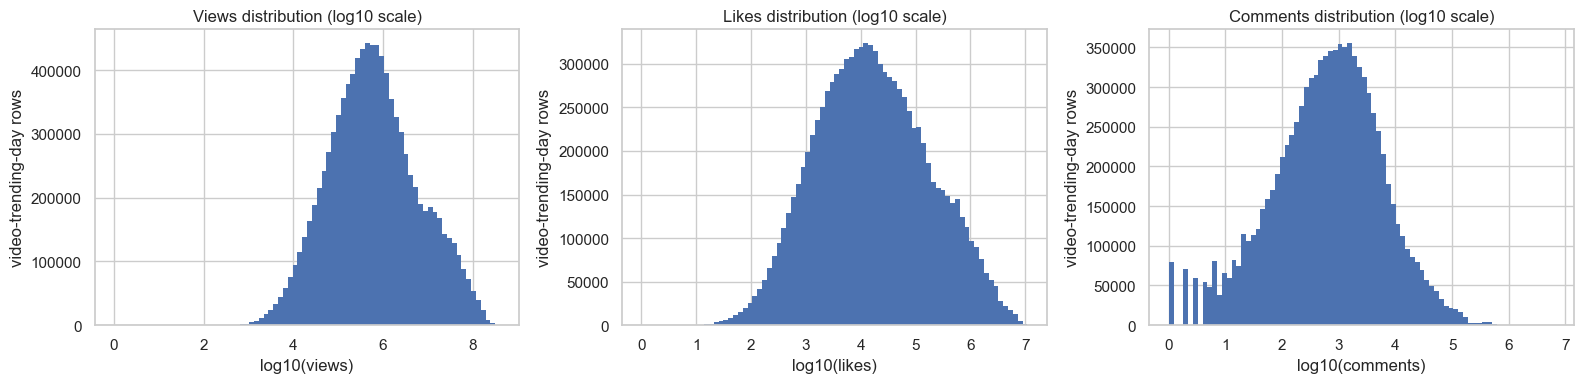

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
count_cols = ['video_view_count', 'video_like_count', 'video_comment_count']
titles = ['Views', 'Likes', 'Comments']

for ax, col, title in zip(axes, count_cols, titles):
    values = df[col].dropna().astype('float64')
    values = values[values > 0]
    ax.hist(np.log10(values), bins=80, color='#4C72B0', edgecolor='none')
    ax.set_title(f'{title} distribution (log10 scale)')
    ax.set_xlabel(f'log10({title.lower()})')
    ax.set_ylabel('video-trending-day rows')

plt.tight_layout()
plt.savefig(FIG_DIR / 'count_distributions_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Correlation of features with `video_view_count`

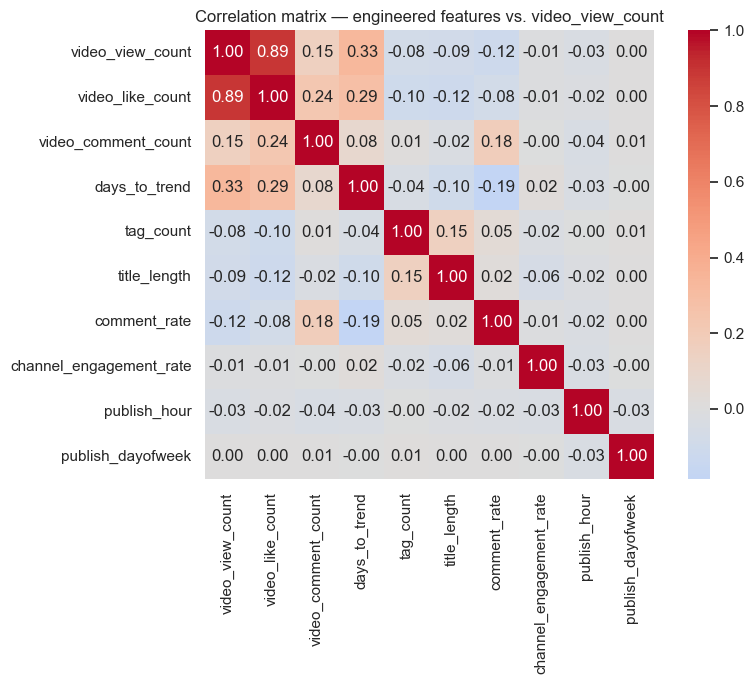

Correlation with video_view_count, sorted:
video_view_count           1.000000
video_like_count           0.889442
days_to_trend              0.331520
video_comment_count        0.153559
publish_dayofweek          0.002761
channel_engagement_rate   -0.009548
publish_hour              -0.032020
tag_count                 -0.082286
title_length              -0.087388
comment_rate              -0.115416
Name: video_view_count, dtype: float64


In [3]:
corr_cols = [
    'video_view_count', 'video_like_count', 'video_comment_count',
    'days_to_trend', 'tag_count', 'title_length', 'comment_rate',
    'channel_engagement_rate', 'publish_hour', 'publish_dayofweek',
]
corr_matrix = df[corr_cols].astype('float64').corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation matrix — engineered features vs. video_view_count')
plt.tight_layout()
plt.show()

print('Correlation with video_view_count, sorted:')
print(corr_matrix['video_view_count'].sort_values(ascending=False))

## 3. Views by `video_category_id`

Category is already a human-readable string in this dataset (not a numeric code), so labels are directly usable. Using median-per-category bars rather than a raw boxplot — with ~10M rows, medians aggregate cleanly and are more legible than an overplotted boxplot.

**Small-sample-size check**: raw medians were initially dominated by an artifact — categories/countries with very few trending entries produce extreme, noisy medians (see the country chart below for the more dramatic case). To correct for this, every group is shown with its row count `n`, and groups with `n < MIN_N` (1,000) are excluded from the ranking chart and reported separately instead of being silently dropped.

Categories total: 15
Categories with n >= 1,000: 14
Categories excluded (n < 1,000): 1

Excluded categories (name, n, median_views):
                        n  median_views
video_category_id                      
Nonprofits & Activism  12     1503839.5


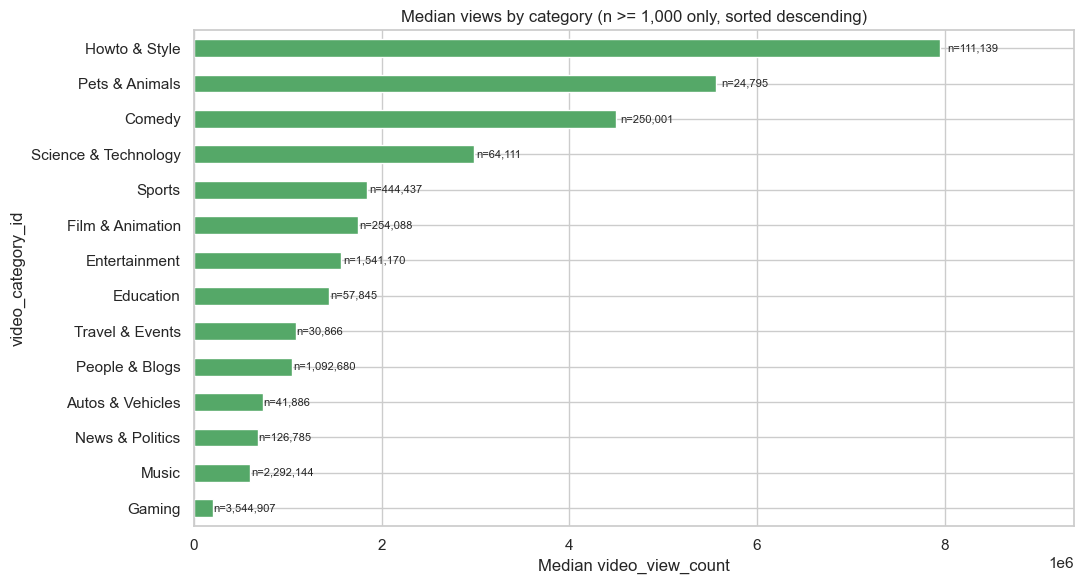

,n,median_views
video_category_id,,
Howto & Style,111139,7946337.0
Pets & Animals,24795,5565783.0
Comedy,250001,4499454.0
Science & Technology,64111,2979485.0
Sports,444437,1846327.0
Film & Animation,254088,1748611.0
Entertainment,1541170,1571673.0
Education,57845,1439858.0
Travel & Events,30866,1083729.0


In [4]:
MIN_N = 1000

category_counts = df.groupby('video_category_id', observed=True)['video_view_count'].count()
category_medians_all = df.groupby('video_category_id', observed=True)['video_view_count'].median()
category_stats = pd.DataFrame({'n': category_counts, 'median_views': category_medians_all})
category_stats = category_stats.sort_values('median_views', ascending=False)

included_categories = category_stats[category_stats['n'] >= MIN_N]
excluded_categories = category_stats[category_stats['n'] < MIN_N].sort_values('median_views', ascending=False)

print(f'Categories total: {len(category_stats)}')
print(f'Categories with n >= {MIN_N:,}: {len(included_categories)}')
print(f'Categories excluded (n < {MIN_N:,}): {len(excluded_categories)}')
print()
print('Excluded categories (name, n, median_views):')
print(excluded_categories)

category_medians = included_categories['median_views'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, max(6, len(category_medians) * 0.4)))
category_medians.plot(kind='barh', ax=ax, color='#55A868')
ax.invert_yaxis()
for i, (cat, median_views) in enumerate(category_medians.items()):
    n = included_categories.loc[cat, 'n']
    ax.text(median_views * 1.01, i, f'n={n:,.0f}', va='center', fontsize=8)
ax.set_xlim(right=category_medians.max() * 1.18)
ax.set_xlabel('Median video_view_count')
ax.set_ylabel('video_category_id')
ax.set_title(f'Median views by category (n >= {MIN_N:,} only, sorted descending)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'views_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

included_categories.sort_values('median_views', ascending=False)

## 4. Trending list composition by market size: local vs. globally-viral content

Raw median views by country looked like a geographic engagement signal, but we tested that directly: for each video, we counted how many distinct countries it trended in, and measured what share of each country's trending rows belong to videos that also trended in 20+ other countries (a "global hit"). The result: Malta (48.93%) and Slovenia (47.69%) have roughly **20-30x** the global-hit share of the US (9.01%), India (2.43%), or Japan (1.61%). Malta's top-10-by-views rows are dominated by a single globally viral music video (trending in 90 other countries) — nothing market-specific.

**This is the headline chart for this section**: `global_hit_share` by country, all 111 countries. Median views is kept below only as a secondary reference — it's confounded by this composition effect and should not be read as a standalone engagement signal by country.

Countries: 111
Countries with n >= 1,000: 111 (all of them clear the threshold, consistent with the earlier filtering check)


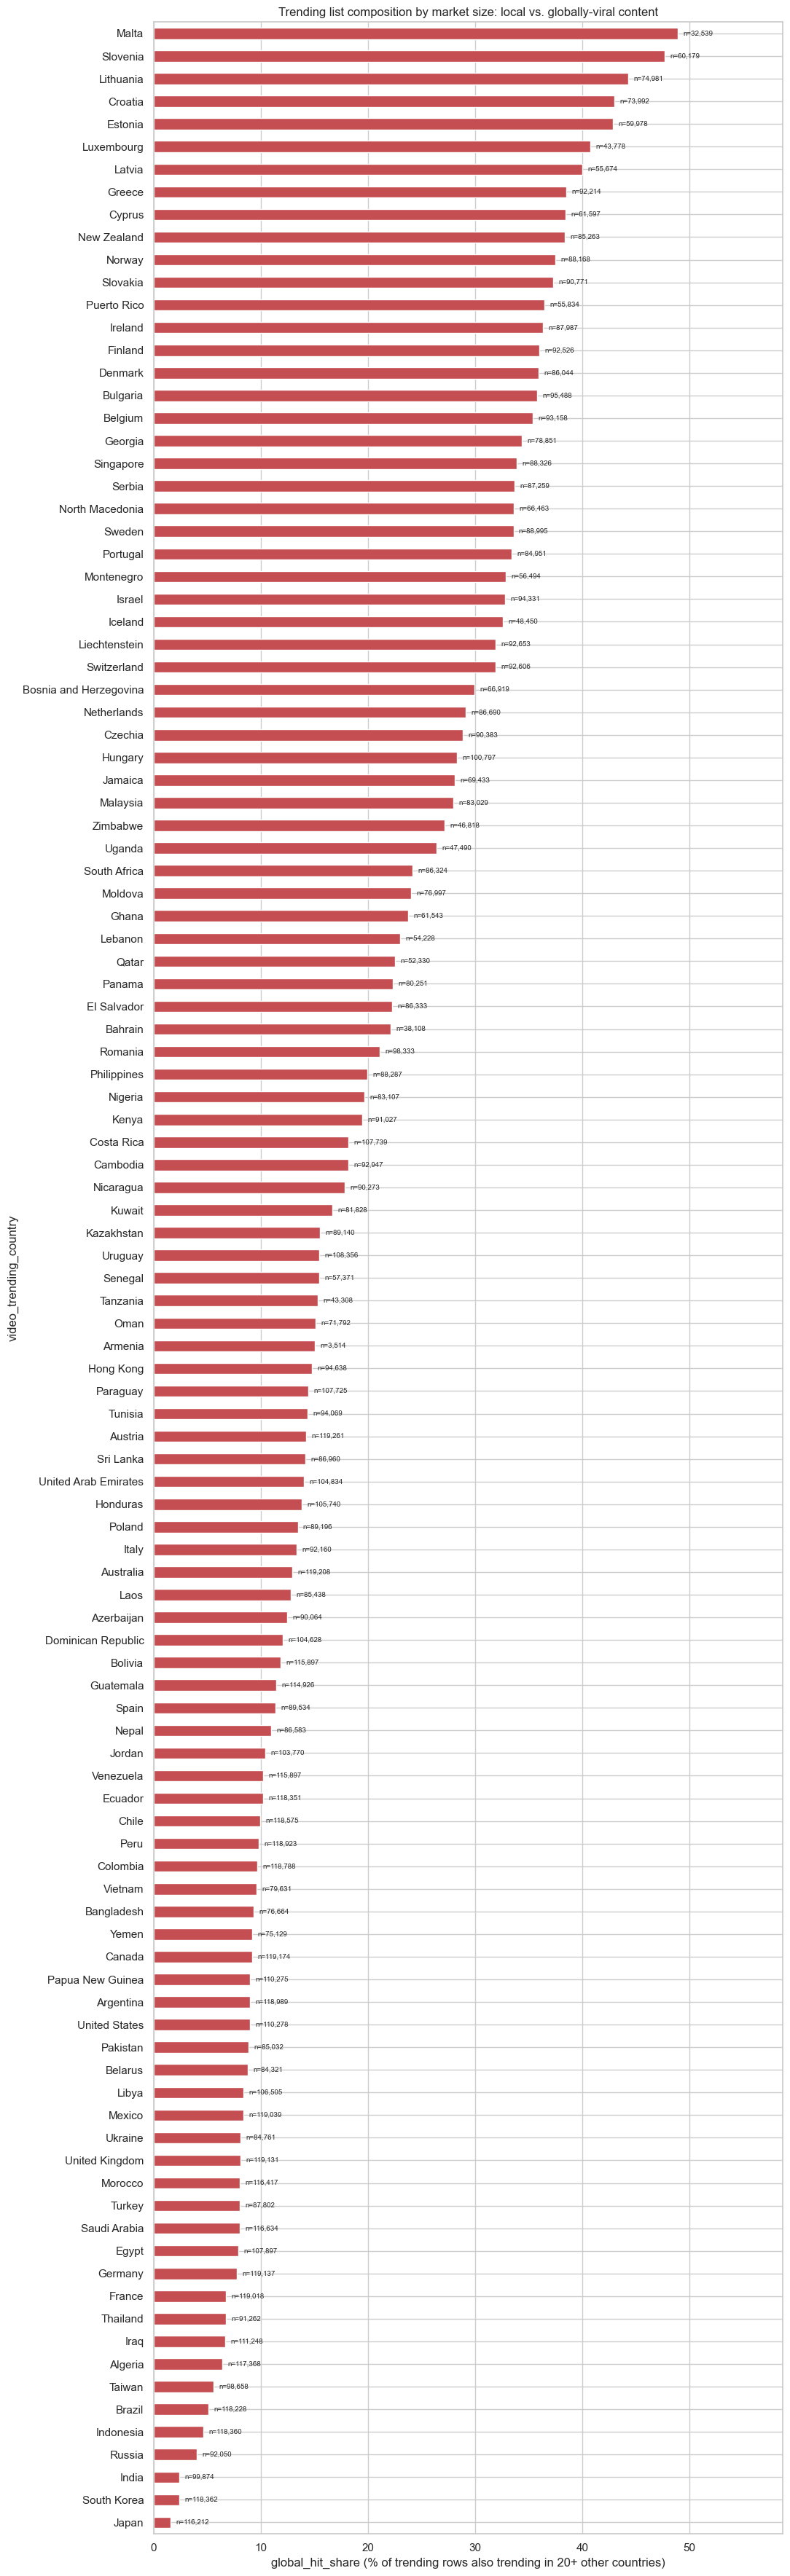


SECONDARY REFERENCE ONLY — median views by country is confounded by global_hit_share above; a high median here often just means a market whose trending list is padded with global hits, not higher local engagement.

                             n  global_hit_share  median_views
video_trending_country                                        
Malta                    32539          0.489290    12486951.0
Slovenia                 60179          0.476927    10125664.0
North Macedonia          66463          0.336172     7088744.0
Cyprus                   61597          0.384662     6877646.0
Luxembourg               43778          0.407602     6345943.0
Estonia                  59978          0.428457     6310668.0
Iceland                  48450          0.326089     6204856.5
Latvia                   55674          0.400097     3377021.0
Georgia                  78851          0.343458     2603015.0
Puerto Rico              55834          0.364652     2249551.0
Lithuania                749

In [5]:
# Per-video global reach: how many distinct countries did each video trend in?
video_reach = df.groupby('video_id')['video_trending_country'].nunique()
video_reach.name = 'total_countries'
df = df.merge(video_reach, on='video_id', how='left')
df['other_countries'] = df['total_countries'] - 1
df['is_global_hit'] = df['other_countries'] >= 20  # trended in 20+ OTHER countries

country_reach_stats = df.groupby('video_trending_country', observed=True).agg(
    n=('video_view_count', 'count'),
    global_hit_share=('is_global_hit', 'mean'),
    median_views=('video_view_count', 'median'),
).sort_values('global_hit_share', ascending=False)

print(f'Countries: {len(country_reach_stats)}')
print(f'Countries with n >= {MIN_N:,}: {(country_reach_stats["n"] >= MIN_N).sum()} '
      f'(all of them clear the threshold, consistent with the earlier filtering check)')

# --- HEADLINE CHART: global_hit_share by country, all 111, sorted descending ---
fig, ax = plt.subplots(figsize=(11, max(8, len(country_reach_stats) * 0.32)))
bars_data = country_reach_stats['global_hit_share'] * 100
bars_data.plot(kind='barh', ax=ax, color='#C44E52')
ax.invert_yaxis()
for i, (country, pct) in enumerate(bars_data.items()):
    n = country_reach_stats.loc[country, 'n']
    ax.text(pct + 0.5, i, f'n={n:,.0f}', va='center', fontsize=7)
ax.set_xlim(right=bars_data.max() * 1.2)
ax.set_xlabel('global_hit_share (% of trending rows also trending in 20+ other countries)')
ax.set_ylabel('video_trending_country')
ax.set_title('Trending list composition by market size: local vs. globally-viral content')
plt.tight_layout()
plt.savefig(FIG_DIR / 'views_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SECONDARY REFERENCE: median views, confounded by composition above ---
print()
print('SECONDARY REFERENCE ONLY — median views by country is confounded by '
      'global_hit_share above; a high median here often just means a market '
      'whose trending list is padded with global hits, not higher local engagement.')
print()
pd.set_option('display.max_rows', None)
print(country_reach_stats[['n', 'global_hit_share', 'median_views']].sort_values('median_views', ascending=False))
pd.reset_option('display.max_rows')

## 5. `days_to_trend` distribution

How fast videos trend after publishing, and whether the small negative tail we flagged during feature engineering (clock skew, min ≈ -0.77 days) is a meaningful bump or genuinely negligible.

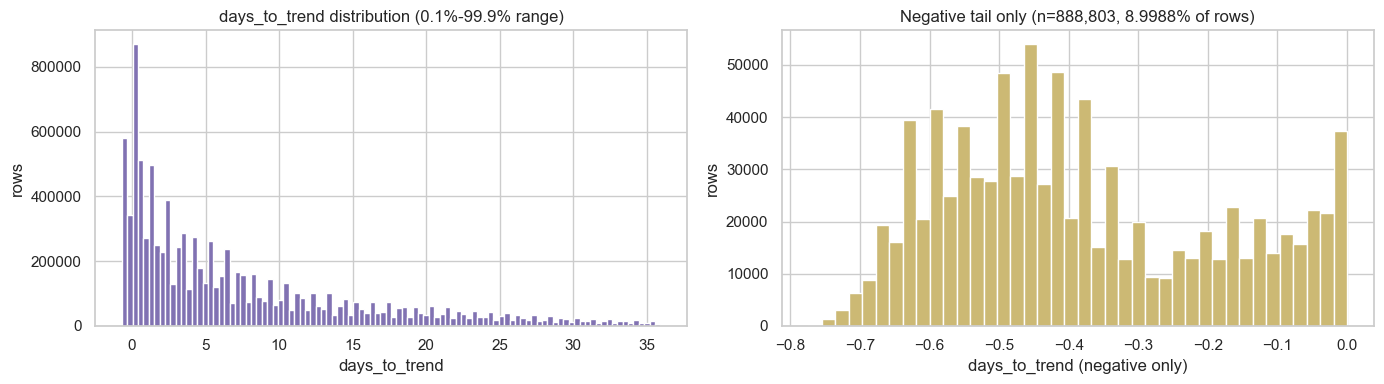

Rows with negative days_to_trend: 888,803 (8.9988% of 9,876,866)
Min: -0.774  Max: 37.083  Median: 4.372


In [6]:
values = df['days_to_trend'].dropna()
pct_negative = (values < 0).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(values, bins=100, range=(values.quantile(0.001), values.quantile(0.999)), color='#8172B2')
axes[0].set_title('days_to_trend distribution (0.1%-99.9% range)')
axes[0].set_xlabel('days_to_trend')
axes[0].set_ylabel('rows')

negative_tail = values[values < 0]
if len(negative_tail):
    axes[1].hist(negative_tail, bins=40, color='#CCB974')
axes[1].set_title(f'Negative tail only (n={len(negative_tail):,}, {pct_negative:.4%} of rows)')
axes[1].set_xlabel('days_to_trend (negative only)')
axes[1].set_ylabel('rows')

plt.tight_layout()
plt.savefig(FIG_DIR / 'days_to_trend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Rows with negative days_to_trend: {len(negative_tail):,} ({pct_negative:.4%} of {len(values):,})")
print(f"Min: {values.min():.3f}  Max: {values.max():.3f}  Median: {values.median():.3f}")

## 6. `publish_hour` and `publish_dayofweek` distributions

Is there a visible pattern in when trending videos get published, or does it look roughly uniform?

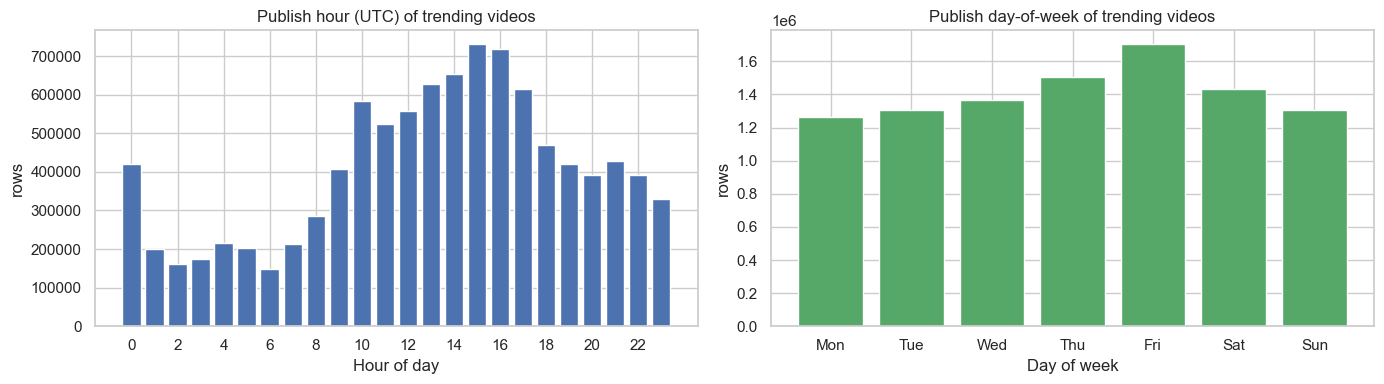

Publish hour value counts (top 5):
publish_hour
15    730177
16    719386
14    652487
13    627667
17    615812
Name: count, dtype: int64

Publish day-of-week value counts:
publish_dayofweek
Mon    1261093
Tue    1304516
Wed    1365704
Thu    1508018
Fri    1701400
Sat    1430201
Sun    1305934
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_counts = df['publish_hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='#4C72B0')
axes[0].set_title('Publish hour (UTC) of trending videos')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('rows')
axes[0].set_xticks(range(0, 24, 2))

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['publish_dayofweek'].value_counts().sort_index()
axes[1].bar([day_labels[i] for i in day_counts.index], day_counts.values, color='#55A868')
axes[1].set_title('Publish day-of-week of trending videos')
axes[1].set_xlabel('Day of week')
axes[1].set_ylabel('rows')

plt.tight_layout()
plt.show()

print('Publish hour value counts (top 5):')
print(hour_counts.sort_values(ascending=False).head())
print()
print('Publish day-of-week value counts:')
print(day_counts.rename(index=dict(enumerate(day_labels))))

## 7. Summary — key numbers for the write-up

(Computed here so the plain-language summary below is drawn from actual output, not estimated.)

In [8]:
print('Top 5 categories by median views (n >= MIN_N):')
print(included_categories.sort_values('median_views', ascending=False).head(5))
print()
print('Bottom 5 categories by median views (n >= MIN_N):')
print(included_categories.sort_values('median_views', ascending=False).tail(5))
print()
print('Top 10 countries by global_hit_share (the headline metric now):')
print(country_reach_stats.sort_values('global_hit_share', ascending=False).head(10))
print()
print('Bottom 10 countries by global_hit_share:')
print(country_reach_stats.sort_values('global_hit_share', ascending=False).tail(10))
print()
corr_no_self = corr_matrix['video_view_count'].drop('video_view_count')
print('Correlation with views, ranked by |correlation|:')
print(corr_no_self.reindex(corr_no_self.abs().sort_values(ascending=False).index))
print()
print(f'% negative days_to_trend: {pct_negative:.4%}')
print(f'Median days_to_trend: {values.median():.2f}')
print(f'Peak publish hour: {hour_counts.idxmax()} ({hour_counts.max():,} rows)')
print(f'Peak publish day: {day_labels[day_counts.idxmax()]} ({day_counts.max():,} rows)')
print(f'Views/category max-to-min ratio (n >= MIN_N): {category_medians.max() / category_medians.min():.1f}x')
print(f'global_hit_share max-to-min ratio across countries: '
      f'{country_reach_stats["global_hit_share"].max() / country_reach_stats["global_hit_share"].min():.1f}x')
print()
for c in ['Malta', 'Slovenia', 'North Macedonia', 'United States', 'India', 'Japan']:
    row = country_reach_stats.loc[c]
    rank = list(country_reach_stats.sort_values('global_hit_share', ascending=False).index).index(c) + 1
    print(f'{c:20s} n={row["n"]:>9,.0f}  global_hit_share={row["global_hit_share"]:.2%}  '
          f'rank={rank} of {len(country_reach_stats)}')

Top 5 categories by median views (n >= MIN_N):
                           n  median_views
video_category_id                         
Howto & Style         111139     7946337.0
Pets & Animals         24795     5565783.0
Comedy                250001     4499454.0
Science & Technology   64111     2979485.0
Sports                444437     1846327.0

Bottom 5 categories by median views (n >= MIN_N):
                         n  median_views
video_category_id                       
People & Blogs     1092680     1050178.0
Autos & Vehicles     41886      732822.5
News & Politics     126785      678891.0
Music              2292144      602095.0
Gaming             3544907      199302.0

Top 10 countries by global_hit_share (the headline metric now):
                            n  global_hit_share  median_views
video_trending_country                                       
Malta                   32539          0.489290    12486951.0
Slovenia                60179          0.476927    10125664.0
L

Median days_to_trend: 4.37
Peak publish hour: 15 (730,177 rows)
Peak publish day: Fri (1,701,400 rows)
Views/category max-to-min ratio (n >= MIN_N): 39.9x
global_hit_share max-to-min ratio across countries: 30.4x

Malta                n=   32,539  global_hit_share=48.93%  rank=1 of 111
Slovenia             n=   60,179  global_hit_share=47.69%  rank=2 of 111
North Macedonia      n=   66,463  global_hit_share=33.62%  rank=22 of 111
United States        n=  110,278  global_hit_share=9.01%  rank=89 of 111
India                n=   99,874  global_hit_share=2.43%  rank=109 of 111
Japan                n=  116,212  global_hit_share=1.61%  rank=111 of 111


## Key takeaways

1. **[Headline] The country views gap is trending-list composition, not audience engagement — confirmed and quantified, not assumed.** Initial medians looked suspicious (Malta ~12.5M vs. the US mid-pack), so we tested two hypotheses in sequence rather than guessing. First, small sample size: filtering to `n >= 1,000` excluded only 1 of 15 categories and 0 of 111 countries, so the disparity survives at huge sample sizes (Malta n=32,539; US n=110,278) — not noise. Second, globally-viral padding: we measured what share of each country's trending rows belong to videos that also trended in 20+ other countries simultaneously. Malta (48.93%) and Slovenia (47.69%) top the list; Japan (1.61%), South Korea (2.39%), and India (2.43%) sit at the bottom — a **30.4x gap**. Malta's top 10 highest-view trending rows are 9/10 the same single globally viral music video (trending in 90 other countries at once) — nothing Malta-specific. The country chart has been retitled and reframed around `global_hit_share` accordingly; median views by country is now shown only as a secondary reference table with an explicit confounding caveat, not the headline comparison.

2. **Likes are by far the strongest predictor of views.** Correlation with `video_view_count` is 0.89 — no other feature comes close (`days_to_trend` is a distant second at 0.33, `video_comment_count` third at 0.15).

3. **Category shows a real 40x gap even after the sample-size check, and it holds up as genuine signal.** Music staying near the bottom (n=2,292,144, one of the largest samples in the whole dataset, median 602,095) and Gaming being lowest overall (n=3,544,907, median 199,302) are both confirmed real findings, not artifacts — worth keeping for modeling rather than treating as noise.

4. **The negative `days_to_trend` tail is a real, sizeable data quality issue, not a rounding artifact.** 9.0% of rows show a video trending *before* its recorded publish timestamp. This needs an explicit decision (drop, clip, or investigate the timestamp source) before it feeds into a baseline model.
